In [1]:
import shutil
import pandas as pd
import random

import copy
import numpy as np # Import numpy for checking finite values
import matplotlib.pyplot as plt # Import matplotlib for potential debugging

import os
import math # Import math for ceil
#from sklearn.manifold import TSNE # Import TSNE to check default perplexity



import os
import glob
import json
import numpy as np
#import tensorflow as tf


C:\Users\admin\AppData\Local\Temp\ipykernel_800\2033071358.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
all_tested_models = {} 
direct_f1 = {}
direct_acc = {}

In [3]:
import sys
fixed_path = 'C:\\Users\\admin\\0.Master_Thesis\\'
#fixed_path = 'C:\\Users\\Enrico Didoli\\0.Master_Thesis\\'
if fixed_path not in sys.path:
    sys.path.append(fixed_path)

old_cellcnn_path = f'{fixed_path}CellCNN/Old_CellCNN/'
if old_cellcnn_path not in sys.path:
    sys.path.append(old_cellcnn_path)

general_functions_path = f'{fixed_path}General_Functions/'
if general_functions_path not in sys.path:
    sys.path.append(general_functions_path)

save_path = f'{fixed_path}CellCNN/results/'
if save_path not in sys.path:
    sys.path.append(save_path)
old_save_path = f'{save_path}old/'
if old_save_path  not in sys.path:
    sys.path.append(old_save_path )


In [4]:
decache_files = ['timepoints_elaboration', 'results_elaboration', 'new_datasets_generation',
                 'old_cellCnn.model', 'old_cellCnn.utils', 'old_cellCnn.downsample']

# Rimuovi il modulo specifico dalla cache
from timepoints_elaboration import remove_from_cache
remove_from_cache(decache_files)

from results_elaboration import extract_hyper, phenotype_prediction, default_serializer, show_hyperparameters
from results_elaboration import elaborate_predictions, show_hyper


timepoints_elaboration rimosso dalla cache
results_elaboration non trovato nella cache
new_datasets_generation non trovato nella cache
old_cellCnn.model non trovato nella cache
old_cellCnn.utils non trovato nella cache
old_cellCnn.downsample non trovato nella cache


In [5]:
import os

#percorso = "/percorso/desiderato"

# Ottieni solo i nomi delle cartelle
cartelle = [
    nome for nome in os.listdir(old_save_path)
    if os.path.isdir(os.path.join(old_save_path, nome))
]

def extract_num(folder_name):
    if 'model_' in folder_name:
        return folder_name
        
models = [
    extract_num(model) for model in cartelle 
    if extract_num(model) is not None
]

#models = ['model_1','model_2', 'model_3']
print(models)

['model_04_12_0.0001%_4', 'model_04_12_0.001%_3', 'model_10_11_1000_1', 'model_10_11_200_0.0001_1', 'model_10_11_200_1', 'model_10_11_500_1', 'model_Old_04_12_original_1', 'model_Old_10_11_200_1']


In [6]:
def load_saved_data(save_path, model_folder_name):
    print(f'{model_folder_name}')
    save_path = f'{save_path}{model_folder_name}\\'
    print('New Generated test datasets')
    
    with open(f'{save_path}configuration.json', "r", encoding="utf-8") as f:
        configuration = json.load(f)

    """for boxplot data""" 
    with open(f'{save_path}original_old_per_donor_resampled_test_y.json', "r", encoding="utf-8") as f:
        per_donor_resampled_test_y = json.load(f)
        
    with open(f'{save_path}original_old_trials_pred_lists.json', "r", encoding="utf-8") as f:
        trials_pred_lists = json.load(f)

    """for direct predictio"""
            
    with open(f'{save_path}original_old_predictions_list.json', "r", encoding="utf-8") as f:
        imported_predictions = json.load(f)

    with open(f'{save_path}original_old_results_list.json', "r", encoding="utf-8") as f:
        imported_results = json.load(f)

    with open(f'{save_path}original_old_test_y.json', "r", encoding="utf-8") as f:
        imported_test_y = json.load(f)
    tot_per_tr_f1_scores, blast_perc = [], []
    
    """threshold tuning and blast_perc"""
    try:
        with open(f'{save_path}original_old_tuning_thr_f1_scores.json', "r", encoding="utf-8") as f:
            tot_per_tr_f1_scores = json.load(f)  ################################################### next time store the pairs of f1scores instead
    
        with open(f'{save_path}original_old_timepoints_blast_perc.json', "r", encoding="utf-8") as f:
            blast_perc = json.load(f)
    except:
        with open(f'{save_path}original_old_threshold.json', "r", encoding="utf-8") as f:
            tot_per_tr_f1_scores = json.load(f)  ################################################### next time store the pairs of f1scores instead
        with open(f'{save_path}original_old_timepoints_blast_perc.json', "r", encoding="utf-8") as f:
            blast_perc= json.load(f)  ################################################### next time store the pairs of f1scores instead
    
        
    else:
        with open(f'{save_path}original_old_tuning_thr_f1_scores.json', "r", encoding="utf-8") as f:
            tot_per_tr_f1_scores = json.load(f)  ################################################### next time store the pairs of f1scores instead
    
        with open(f'{save_path}original_old_timepoints_blast_perc.json', "r", encoding="utf-8") as f:
            blast_perc = json.load(f)

    return per_donor_resampled_test_y , trials_pred_lists, imported_predictions, imported_results, imported_test_y, tot_per_tr_f1_scores, blast_perc
    
def elaborate_metrics(imported_predictions, imported_test_y, results = False):
    #print(imported_predictions)
    new_pred_phenotype_df_1, new_accuracy_list_1, new_f1_score_list_1 = elaborate_predictions(imported_predictions, imported_test_y, results = results)
    return new_accuracy_list_1, new_f1_score_list_1


def show_threshold_tuning(tot_per_tr_f1_scores):

    """ Best Threshold selection section """
    # find maximum value in the list of f1_scores
    max_f1 = max(tot_per_tr_f1_scores)

    # extract all indexes with the maximum f1_score
    best_thresholds_idx = []
    best_thresholds_idx = [i for i, f1 in enumerate(tot_per_tr_f1_scores) if f1 == max_f1]

    # whether multiple threholds provides the maximum f1_score, the median is taken
    best_threshold = np.median(best_thresholds_idx) # returns the index, but indexes start from 0

    plt.plot(list(range(1, 101)), tot_per_tr_f1_scores)
    plt.vlines(x=best_threshold + 1, ymin = 0, ymax = 1, color='red', linestyle='--')
    print(f'Chosen threshold: {best_threshold + 1}. Associated F1_score: {tot_per_tr_f1_scores[int(best_threshold)]}' )
    
    return best_threshold + 1 

from sklearn.metrics import f1_score, accuracy_score, recall_score

def final_trials_prediction(total_trial_pred_lists, per_donor_original_test_y, per_donor_resampled_test_y, best_threshold):
    from sklearn.metrics import f1_score
    """ Elaborate data to show distribution of trial results over the entire set of timepoints and patiets"""
    prob_data = []
    f1_data = []
    boxplot_data = []
    
    for patient, patient_ys, patient_resampled_y in zip(total_trial_pred_lists, per_donor_original_test_y, per_donor_resampled_test_y):

        for file, true_file_y, true_resampled_y in zip(patient, patient_ys, patient_resampled_y):
            label_str = "Positive" if true_file_y == 1 else "Negative"
            
            file_boxplot_data = []
            file_f1_data = []
            
            for trial in file: # from each file multiple samples has been generated. each sample has been predicted 10 times using the same 'best' model but using a different seed each time
                             # each sub is a pediction of the 20 samples of a single file

                trial_prob = np.mean(trial) # mean of the probabilities of the subsets
                trial_pred = (np.array(trial) >= best_threshold*0.01).astype(int) # label every trial
                trial_f1 =  f1_score(true_resampled_y, trial_pred, pos_label = 1, zero_division=1) # evaluate every trial

                # corret fomat for violin plot
                prob_data.append({
                "True_Label": label_str,
                "File_Score": trial_prob
                })
                
                file_boxplot_data.append(trial_prob)
                file_f1_data.append(trial_f1)

            # save probabilites for grouped boxplot visualization (file-level)
            boxplot_data.append({
                "True_Label": true_file_y,
                "File_trials_scores": file_boxplot_data
                })
            
            f1_data.append({
                "True_Label": true_file_y,
                "File_trials_scores": file_f1_data
                })
                
    return prob_data, boxplot_data, f1_data

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def show_violin_plot(plot_data, threshold):
    # Convert your data into a DataFrame
    df = pd.DataFrame(plot_data)
    
    # --- Create the plot ---
    plt.figure(figsize=(10, 6))
    
    # A Violin plot is like a boxplot but shows the full distribution
    sns.violinplot(
        x="True_Label", 
        y="File_Score", 
        data=df,
        order=["Negative", "Positive"] # Ensure this order
    )
    
    # You can also add a swarmplot to see the individual points
    sns.swarmplot(
        x="True_Label",
        y="File_Score",
        data=df,
        color="black",
        alpha=0.2, # Make points transparent
        size=2,
        order=["Negative", "Positive"]
    )
    
    # --- Add your threshold line! ---
    plt.axhline(y= threshold*0.01, color='red', linestyle='--', label=f'Tuned Threshold ({threshold})')
    #plt.ylim(-0.05, 1.05) # (Set the y-axis limit, 1.05 gives a little space)
    #plt.ylim(0.35, 0.55)
    plt.title('Positive Score Distribution vs. True Label (Across All Trials)')
    plt.ylabel('Positive Score')
    plt.xlabel('True file Label')
    plt.legend()
    plt.show()
def robust_prediction_labelling(trials_pred_lists, threshold):
    patient_timepoints_labels = []
    for patient in trials_pred_lists:
        file_labels = []
        for file in patient:
            positive_probs_mean = np.mean(file , axis=0) #column mean
            mean_timepoint_probs = np.mean(positive_probs_mean) #row mean to get the positive scores
         
            if mean_timepoint_probs >= threshold*0.01:
                file_labels.append(1)
            else:
                file_labels.append(0)
        patient_timepoints_labels.append(file_labels)
    return patient_timepoints_labels 
#print(patient_timepoints_labels)

def flatten(nested):
    if nested is None:
        return []
    if not isinstance(nested, (list, tuple)):
        return [nested]
    result = []
    for item in nested:
        result.extend(flatten(item))
    return result


import matplotlib.patches as mpatches

def show_probabilities_boxplots(patient_timepoints_labels, imported_test_y, boxplot_data, blast_perc, threshold):
    pred_labels_flat = flatten(patient_timepoints_labels)
    true_labels_flat = flatten(imported_test_y)
    
    timepoints_labels = [timepoint["True_Label"] for i, timepoint in enumerate(boxplot_data)]
    timepoints_trials_scores = [timepoint["File_trials_scores"] for timepoint in boxplot_data]
    
    
    # --- Your Solution (One Line) ---
    # Create a figure and axes
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # 2. Plot the boxplot on the first axes (ax1)
    ax1.boxplot(timepoints_trials_scores, labels=timepoints_labels)
    ax1.set_xlabel("Files' True Labels (Bottom)")
    ax1.set_ylabel("Probabilites of being predicted as Positive")
    
    # 3. Create the SECOND axes (ax2)
    ax2 = ax1.twiny()
    ax1.set_xlim(0, 16.5)
    
    # 4. Configure the second axes
    # Make ax2 have the same limits and ticks as ax1
    ax2.set_xlim(ax1.get_xlim())
    ax2.set_xticks(ax1.get_xticks()) # Positions [1, 2, 3, 4]
    
    # Set the new labels for the top axis
    ax2.set_xticklabels(blast_perc)
    ax2.set_xlabel("Files' Blast Cell % (Top)")
    plt.axhline(y=threshold*0.01, color='red', linestyle='--', label=f'Tuned Threshold ({threshold})')
    
    for i, (p, t) in enumerate(zip(pred_labels_flat, true_labels_flat),  start=1):
        match = p == t
        symbol = "✓" if match else "✗"
        color = "green" if match else "red"
        ax2.text(i, ax1.get_ylim()[1] * 0.7,  #-0.03,  # slightly above top of plot
                symbol, ha='center', va='bottom', fontsize=12, color=color,
                fontweight='bold')

    green_patch = mpatches.Patch(color='green', label='✓ Correct prediction')
    red_patch = mpatches.Patch(color='red', label='✗ Incorrect prediction')
    #ax1.set_ylim(0.35,0.55)
    ax1.legend(handles=[green_patch, red_patch], loc='upper right', fontsize = 'x-small')
    plt.legend()
    plt.title("Trial Predictions Boxplots per Test set File")
    plt.show()


def show_f1_boxplots(f1_data, blast_perc, threshold):
    timepoints_labels = [timepoint["True_Label"] for i, timepoint in enumerate(f1_data)]
    f1_timepoints_trials_scores = [timepoint["File_trials_scores"] for timepoint in f1_data]
    
    # --- Your Solution (One Line) ---
    # Create a figure and axes
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # 2. Plot the boxplot on the first axes (ax1)
    ax1.boxplot(f1_timepoints_trials_scores, labels=timepoints_labels)
    ax1.set_xlabel("Timepoint (Bottom)")
    ax1.set_ylabel("F1 scores")
    
    # 3. Create the SECOND axes (ax2)
    ax2 = ax1.twiny()
    
    # 4. Configure the second axes
    # Make ax2 have the same limits and ticks as ax1
    ax2.set_xlim(ax1.get_xlim())
    ax2.set_xticks(ax1.get_xticks()) # Positions [1, 2, 3, 4]
    
    # Set the new labels for the top axis
    ax2.set_xticklabels(blast_perc)
    ax2.set_xlabel("Group (Top)")
    plt.axhline(y=threshold*0.01, color='red', linestyle='--', label=f'Tuned Threshold ({threshold})')
    
    plt.title("Boxplots with Two X-Axes")
    plt.show()

from sklearn.metrics import f1_score, accuracy_score, recall_score

def elaborate_direct_prediction(imported_predictions, imported_test_y, metric = 'acc'):

    if metric == 'acc':
        pos = 0
    elif metric == 'f1':
        pos = 1

    labels_flat = flatten(imported_test_y)
    # elaborate metric data from imported predictions
    models_metric_lists = []
    metrics = elaborate_metrics(imported_predictions, labels_flat)

    return metrics[pos] # extract the metric in the chosen position


def elaborate_robust_prediction(trials_pred_lists, imported_test_y, threshold):
    # group the files in a single vector
    per_files_preds = []
    for patient in trials_pred_lists:
        per_files_preds += patient
    
    # group the files labels in a single vector
    true_labels_flat = flatten(imported_test_y)
    
    files_trial_scores = []
    for i, file in enumerate(per_files_preds):
        trial_scores = []
        for trial in file:
            trial_scores.append(np.mean(trial)) # mean positive score per trial
        files_trial_scores.append(trial_scores) # for every file, a vector of |trials| each representing a file
        
    f1_model, recall_model, acc_model = [], [], []
    
    model_pred_df = pd.DataFrame(files_trial_scores).T # transpose to work on trial-level
    for trial in model_pred_df.values:
        trial_prediction = (np.array(trial) >= threshold*0.01).astype(int) # for each trial predict labels

        
        f1 = f1_score(true_labels_flat, trial_prediction, pos_label = 1, zero_division=1) # and check f1_score
        f1_model.append(f1)

        rec = recall_score(true_labels_flat, trial_prediction, pos_label = 1, zero_division=1) # and check recall
        recall_model.append(rec)

        acc = accuracy_score(true_labels_flat, trial_prediction) # and check accuracy
        acc_model.append(acc)

    return f1_model, recall_model, acc_model #list of f1_score extracted from each trial

def robust_model_comparison_barplot(all_tested_models, metric, subtitle = False):
    if metric == 'f1':
        pos = 0
        metric_name = 'F1-score'
    elif metric == 'rec':
        pos = 1
        metric_name = 'Recall'
    elif metric == 'acc':
        pos = 2
        metric_name = 'Accuracy'
        
    models_metric = [model[pos] for model in list(all_tested_models.values())]
    models_names = [name.replace('model_', '') for name in list(all_tested_models.keys())]
    
    f1_errors = []
    f1_means = []
    for f1 in models_metric:
        m = np.mean(f1)
        f1_means.append(m)
        s = np.std(f1)
        f1_errors.append(s)
    
    # Colors matching the plot
    colors = ['#0077BB', '#FF8800', '#00BB00', '#DD0000', '#AA55BB']
    
    # Create bar plot
    fig, ax = plt.subplots(figsize=(5, 5))
    bars = ax.bar(models_names, f1_means, yerr=f1_errors, color=colors, edgecolor='black', capsize=5)
    
    # add the text above the bars
    for bar, mean, error in zip(bars, f1_means, f1_errors):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + error,
                f'{mean:.3f}',
                ha='center', va='bottom', fontsize=10)
        
    # Customize
    plt.suptitle(f'{metric_name} per model (Robust Approach)', fontsize=14, fontweight='bold')
    if subtitle:
        ax.set_title(f'{subtitle}', fontsize=11)
    
    ax.set_ylabel(metric_name, fontsize=12)

    # set the limits for a better visualization
    high_limit = np.max(np.array(f1_means) + np.array(f1_errors)) # sum each element in f1_means to its elative in errors. than thake the max of the vector
    
    ax.set_ylim(0, max(1, high_limit + 0.05) ) # Adjust based on your data range
    ax.grid(True, alpha=0.3, axis='y')

    plt.xticks(rotation=60)
    plt.tight_layout()
    plt.show()


def direct_model_comparison_barplot(direct, metric_name, subtitle = False):
    
    models_values = list(direct.values())
    models_names = [name.replace('model_', '') for name in direct.keys()]
    
    errors = []
    means = []
    for val in models_values:
        m = np.mean(val)
        means.append(m)
        s = np.std(val)
        errors.append(s)
    
    # Colors matching the plot
    colors = ['#0077BB', '#FF8800', '#00BB00', '#DD0000', '#AA55BB']
    
    # Create bar plot
    fig, ax = plt.subplots(figsize=(5, 5))
    
    bars = ax.bar(models_names, means, yerr= errors, color=colors, edgecolor='black', capsize=5)
    
    for bar, mean, error in zip(bars, means, errors):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + error,
                f'{mean:.3f}',
                ha='center', va='bottom', fontsize=10)
        
    # Customize
    plt.suptitle(f'Direct Prediction {metric_name} per method', fontsize=14, fontweight='bold')
    if subtitle:
        ax.set_title(f'{subtitle}', fontsize=11)
        
    ax.set_ylabel(metric_name, fontsize=12)
    high_limit = np.max(np.array(means) + np.array(errors))
    
    ax.set_ylim(0, max(1, high_limit + 0.05)) # Adjust based on your data range
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    plt.show()


In [7]:
models = [ 'model_Old_10_11_200_1',  'model_Old_04_12_original_1', 'model_10_11_200_1', 'model_10_11_500_1',  'model_10_11_1000_1',  'model_10_11_200_0.0001_1', 'model_04_12_0.0001%_4', 'model_04_12_0.001%_3']
mod = models[7]

per_donor_resampled_test_y , trials_pred_lists, imported_predictions, imported_results, imported_test_y, tot_per_tr_f1_scores, blast_perc = load_saved_data(f'{old_save_path}', mod)

print(tot_per_tr_f1_scores)
#print(len(tot_per_tr_f1_scores))
print(blast_perc)

model_04_12_0.001%_3
New Generated test datasets
[0.7603305785123967, 0.7603305785123967, 0.7603305785123967, 0.7603305785123967, 0.7603305785123967, 0.7603305785123967, 0.7603305785123967, 0.7603305785123967, 0.7603305785123967, 0.7603305785123967, 0.7603305785123967, 0.7603305785123967, 0.7603305785123967, 0.7603305785123967, 0.7603305785123967, 0.7698744769874477, 0.8, 0.8803827751196173, 0.9154228855721394, 0.9533678756476683, 0.9583333333333334, 0.9583333333333334, 0.9583333333333334, 0.9583333333333334, 0.9583333333333334, 0.9583333333333334, 0.9583333333333334, 0.9583333333333334, 0.9583333333333334, 0.9583333333333334, 0.9583333333333334, 0.9583333333333334, 0.9583333333333334, 0.9583333333333334, 0.9583333333333334, 0.9583333333333334, 0.9633507853403142, 0.9633507853403142, 0.9735449735449735, 0.9735449735449735, 0.967741935483871, 0.9560439560439561, 0.9497206703910615, 0.9005847953216374, 0.8941176470588236, 0.8795180722891566, 0.8641975308641975, 0.8354430379746836, 0.8129

In [8]:
print(len(trials_pred_lists))
print(len(trials_pred_lists[0]))
print(len(trials_pred_lists[0][0]))
print(len(trials_pred_lists[0][0][0]))
print(trials_pred_lists[0][0][0][0])

6
2
10
100
0.6083861390749613


Chosen threshold: 39.5. Associated F1_score: 0.9735449735449735
39.5


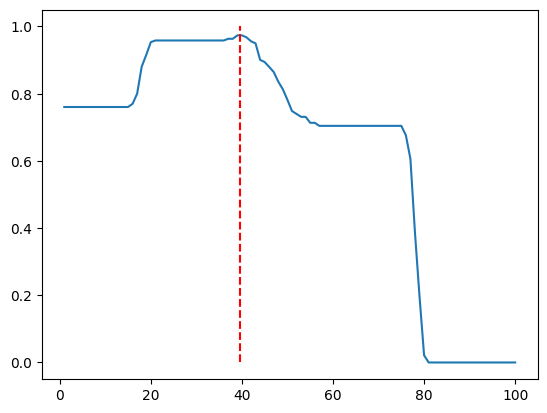

In [9]:
try:
    threshold = show_threshold_tuning(tot_per_tr_f1_scores)
except:
    threshold = tot_per_tr_f1_scores
print(threshold)

In [10]:

patient_timepoints_labels  = robust_prediction_labelling(trials_pred_lists, threshold)
test_total_labels = flatten(patient_timepoints_labels)

print(f'Prediced Timepoints Labels: {patient_timepoints_labels}')
print(f'True Timepoints Labels: {imported_test_y}')


Prediced Timepoints Labels: [[1, 1], [1, 1], [0], [1, 1, 0], [1, 0], [1, 0, 0]]
True Timepoints Labels: [[1, 1], [1, 1], [0], [1, 1, 0], [1, 0], [1, 1, 0]]


Predicted  Labels: [[1, 1], [1, 1], [0], [1, 1, 0], [1, 0], [1, 0, 0]]
Timepoints Labels: [[1, 1], [1, 1], [0], [1, 1, 0], [1, 0], [1, 1, 0]]


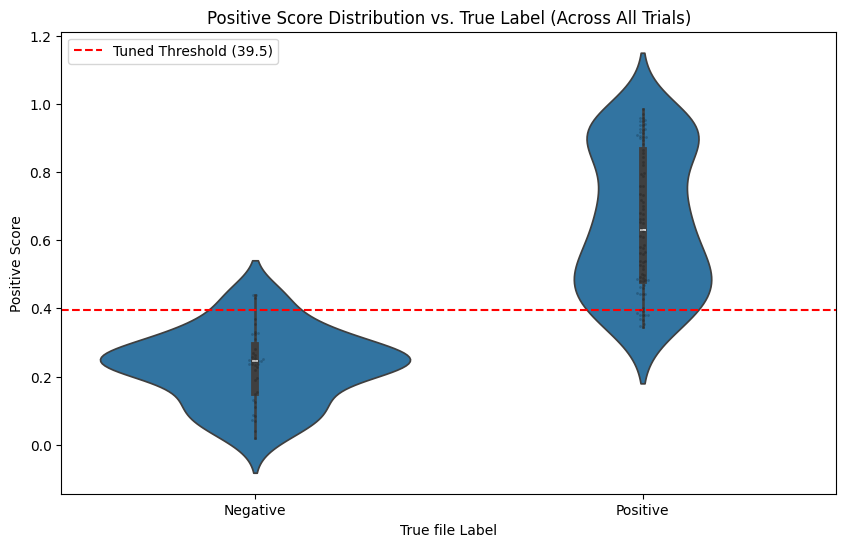

In [11]:

    
print(f'Predicted  Labels: {patient_timepoints_labels}')

print(f'Timepoints Labels: {imported_test_y}')

plot_data, boxplot_data, f1_data = final_trials_prediction(trials_pred_lists, 
                                                           imported_test_y, per_donor_resampled_test_y, threshold)



show_violin_plot(plot_data, threshold)

C:\Users\admin\AppData\Local\Temp\ipykernel_800\2535117548.py:203: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(timepoints_trials_scores, labels=timepoints_labels)


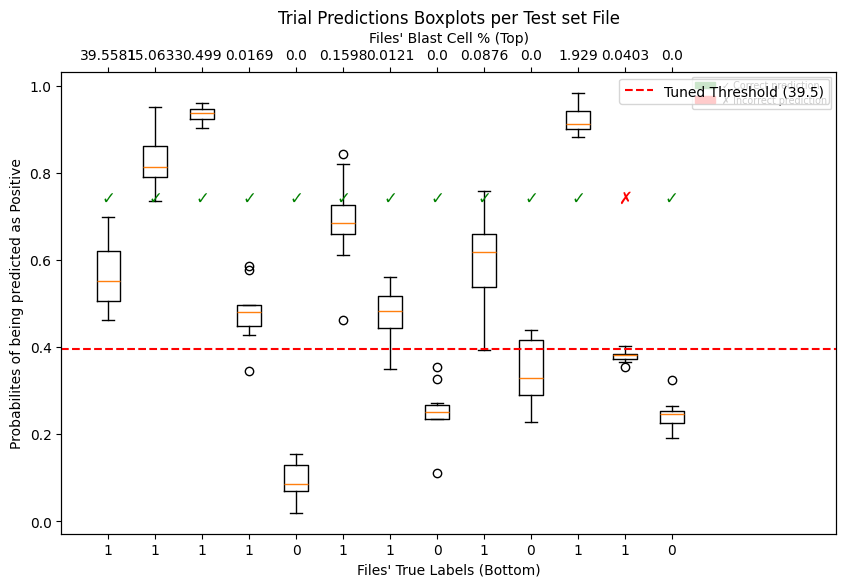

In [12]:

show_probabilities_boxplots(patient_timepoints_labels, imported_test_y, boxplot_data, blast_perc, threshold)


C:\Users\admin\AppData\Local\Temp\ipykernel_800\2535117548.py:247: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(f1_timepoints_trials_scores, labels=timepoints_labels)


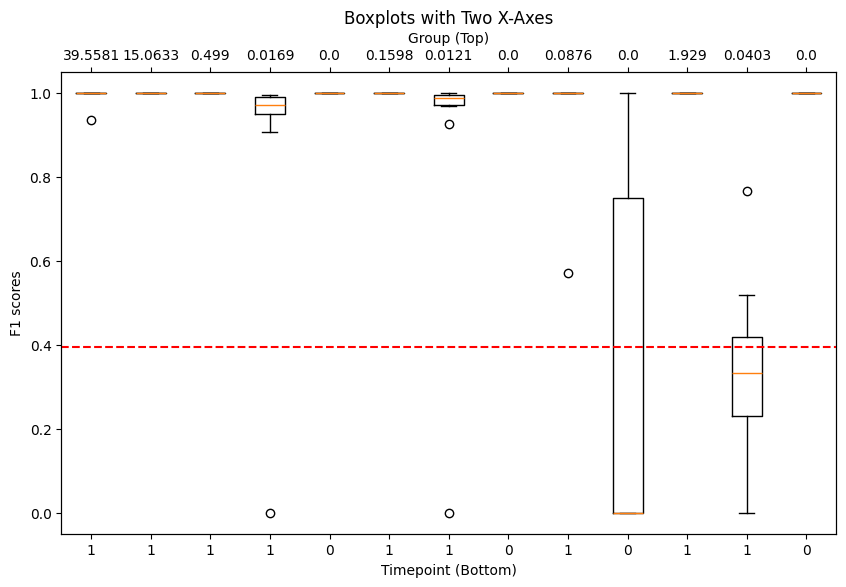

In [13]:

show_f1_boxplots(f1_data, blast_perc, threshold)

In [14]:

'''
print(len(f1_data))
print(threshold)

f1_pred_labels = flatten(patient_timepoints_labels).copy()
for i, file in enumerate(f1_data):
    #print(file)
    true_y, f1s = file.values()
    mean_f1 = np.mean(f1s)
    #print(mean_f1)
    accept = mean_f1 > threshold*0.01
    #print(pred_label)
    if accept == False:
        if f1_true_labels[i] == 0:
            f1_true_labels[i] = 1
        else:
            f1_true_labels[i] = 0

print(f'Previously predicted  Labels: {flatten(patient_timepoints_labels)}')
print(f'Predicted  Labels           : {f1_pred_labels}')
print(f'Files True Labels           : {flatten(imported_test_y)}')
'''

"\nprint(len(f1_data))\nprint(threshold)\n\nf1_pred_labels = flatten(patient_timepoints_labels).copy()\nfor i, file in enumerate(f1_data):\n    #print(file)\n    true_y, f1s = file.values()\n    mean_f1 = np.mean(f1s)\n    #print(mean_f1)\n    accept = mean_f1 > threshold*0.01\n    #print(pred_label)\n    if accept == False:\n        if f1_true_labels[i] == 0:\n            f1_true_labels[i] = 1\n        else:\n            f1_true_labels[i] = 0\n\nprint(f'Previously predicted  Labels: {flatten(patient_timepoints_labels)}')\nprint(f'Predicted  Labels           : {f1_pred_labels}')\nprint(f'Files True Labels           : {flatten(imported_test_y)}')\n"

## Show f1_score boxplots per model

In [15]:
all_tested_models = {} 
direct_f1 = {}
direct_acc = {}

In [16]:
#models = [ 'model_Old_10_11_200_1', 'model_Old_04_12_original_1', 'model_10_11_200_1', 'model_10_11_500_1',  'model_10_11_1000_1',  'model_10_11_200_0.0001_1', 'model_04_12_0.0001%_4', 'model_04_12_0.001%_3']
models = ['model_Old_04_12_original_1', 'model_04_12_0.001%_3',  'model_04_12_0.0001%_4']
models_names = ['orig_CellCNN', 'AS_0.1%', 'AS_0.01%']

#mod = models[1]
#print(mod)
#per_donor_resampled_test_y , trials_pred_lists, imported_predictions, imported_results, imported_test_y, tot_per_tr_f1_scores, blast_perc = load_saved_data(f'{old_save_path}', mod)

model_Old_04_12_original_1
New Generated test datasets
Chosen threshold: 66.0. Associated F1_score: 0.9583333333333334
model_04_12_0.001%_3
New Generated test datasets
Chosen threshold: 39.5. Associated F1_score: 0.9735449735449735
model_04_12_0.0001%_4
New Generated test datasets
Chosen threshold: 41.0. Associated F1_score: 0.9732620320855615
{'orig_CellCNN': [0.7692307692307693, 0.7692307692307693, 0.9230769230769231, 0.8461538461538461, 0.8461538461538461, 0.8461538461538461, 0.8461538461538461, 0.7692307692307693, 0.7692307692307693, 0.8461538461538461], 'AS_0.1%': [0.8461538461538461, 0.7692307692307693, 0.7692307692307693, 0.8461538461538461, 0.8461538461538461, 0.7692307692307693, 0.7692307692307693, 0.8461538461538461, 0.6153846153846154, 0.7692307692307693], 'AS_0.01%': [0.8461538461538461, 0.7692307692307693, 0.8461538461538461, 0.6923076923076923, 0.7692307692307693, 0.6923076923076923, 0.7692307692307693, 0.7692307692307693, 0.7692307692307693, 0.7692307692307693]}
{'orig_C

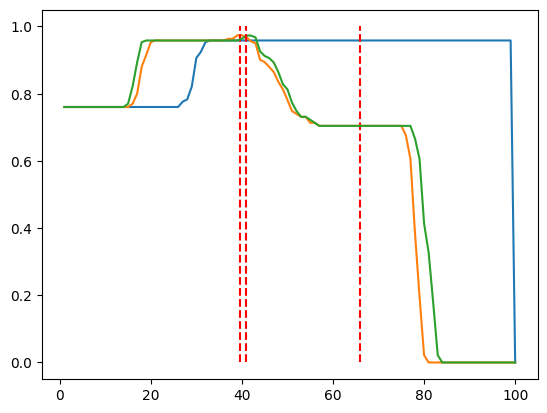

In [17]:
for i, mod in enumerate(models):
    #load data
    per_donor_resampled_test_y , trials_pred_lists, imported_predictions, imported_results, imported_test_y, tot_per_tr_f1_scores, blast_perc = load_saved_data(f'{old_save_path}', mod)

    try:
        threshold = show_threshold_tuning(tot_per_tr_f1_scores)
    except:
        print(mod)
        threshold = tot_per_tr_f1_scores
    
    dir_acc = elaborate_direct_prediction(imported_predictions, imported_test_y, 'acc')
    dir_f1 = elaborate_direct_prediction(imported_predictions, imported_test_y, 'f1')

    mod_n = models_names[i]
    direct_acc[mod_n] = dir_acc
    direct_f1[mod_n] = dir_f1

    metrics_list = elaborate_robust_prediction(trials_pred_lists, imported_test_y, threshold)
    # add the f1_result to the tested model dictionary
    patient_timepoints_labels  = robust_prediction_labelling(trials_pred_lists, threshold)
    test_total_labels = flatten(patient_timepoints_labels)
    all_tested_models[mod_n] = [metrics_list, [patient_timepoints_labels, imported_test_y]] # f1, recall, accuracy


print(direct_acc)
print(direct_f1)
print(all_tested_models)

## CSNN


In [18]:
mod_names = ['csnn', 'AS_csnn']
results_names= ['results','results_1']
for i, res in enumerate(results_names):
    csnn_path = f'{fixed_path}/CSNN/experiment/best_ball_logistic/{res}.csv'

    csnn_results = pd.read_csv(f'{csnn_path}')
    
    print(csnn_results['f1_valid'].to_numpy())
    mod = mod_names[i]
    metrics_list = [csnn_results[met].to_list() for met in ['f1_valid','recall_valid','accuracy_valid']]
    #all_tested_models[mod_name] = csnn_results['f1_valid'].to_list()
    #all_tested_models[mod] = metrics_list
    direct_acc[mod] = metrics_list[2]
    direct_f1[mod] = metrics_list[0]
#print(csnn_results)

#print(all_tested_models[mod_name])

[0. 0.]
[0. 0. 0. 0. 0.]


## Final Results

In [19]:
def robust_model_comparison_barplot(all_tested_models, metric, subtitle = False):
    if metric == 'f1':
        pos = 0
        metric_name = 'F1-score'
    elif metric == 'rec':
        pos = 1
        metric_name = 'Recall'
    elif metric == 'acc':
        pos = 2
        metric_name = 'Accuracy'
        
    models_metric = [model[pos] for model, _ in list(all_tested_models.values())]
    models_names = [name.replace('model_', '') for name in list(all_tested_models.keys())]

    final_predictions = [flatten(final_pred[0]) for _, final_pred in list(all_tested_models.values())]
    true_labels = [flatten(final_pred[1]) for _, final_pred in list(all_tested_models.values())]
    
    for labels in true_labels:
        if true_labels[0] != labels:
            print(f'Warnining: the model analyzed have been tested on different test sets.')
            print(f'Double check the models you are analysing!')
        

    final_f1_score = [f1_score(true_lab, pred, pos_label = 1, zero_division=1) for true_lab, pred in zip(true_labels, final_predictions)] # and check f1_score
    final_f1_score = [f1_score(true_lab, pred, pos_label = 1, zero_division=1) for true_lab, pred in zip(true_labels, final_predictions)] # and check f1_score
    
    # add the text above the bars
    if metric == 'f1':
        final_pred_score = [f1_score(true_lab, pred, pos_label = 1, zero_division=1) for true_lab, pred in zip(true_labels, final_predictions)] # and check f1_score
    if metric == 'rec':
        final_pred_score = [recall_score(true_lab, pred, pos_label = 1, zero_division=1) for true_lab, pred in zip(true_labels, final_predictions)] # and check f1_score
    if metric == 'acc':
        final_pred_score = [accuracy_score(true_lab, pred) for true_lab, pred in zip(true_labels, final_predictions)] # and check f1_score
         
    
    f1_errors = []
    f1_means = []
    for f1 in models_metric:
        m = np.mean(f1)
        f1_means.append(m)
        s = np.std(f1)
        f1_errors.append(s)
    
    # Colors matching the plot
    colors = ['#0077BB', '#FF8800', '#00BB00', '#DD0000', '#AA55BB']
    
    # Create bar plot
    fig, ax = plt.subplots(figsize=(5, 5))
    #bars = ax.bar(models_names, f1_means, yerr=f1_errors, color=colors, edgecolor='black', capsize=5)
    bars = ax.bar(models_names, final_pred_score, yerr=f1_errors, color=colors, edgecolor='black', capsize=5)

    for bar, mean, error, final_score in zip(bars, f1_means, f1_errors, final_pred_score):
        height = bar.get_height()
        
        ax.text(bar.get_x() + bar.get_width()/2., height + error,
                f'{final_score:.3f}',
                ha='center', va='bottom', fontsize=10)
        
    # Customize
    plt.suptitle(f'{metric_name} per model (Robust Approach)', fontsize=14, fontweight='bold')
    if subtitle:
        ax.set_title(f'{subtitle}', fontsize=11)
    
    ax.set_ylabel(metric_name, fontsize=12)

    # set the limits for a better visualization
    max_mean = np.max(np.array(f1_means) + np.array(f1_errors))
    max_preds = np.max(np.array(final_pred_score) + np.array(f1_errors))
    print(max_mean, max_preds)
    high_limit = max(max_mean, max_preds) # sum each element in f1_means to its elative in errors. than thake the max of the vector
    
    ax.set_ylim(0, max(1, high_limit + 0.05) ) # Adjust based on your data range
    ax.grid(True, alpha=0.3, axis='y')

    plt.xticks(rotation=60)
    plt.tight_layout()
    plt.show()

0.981198056638672 1.0136910538375516


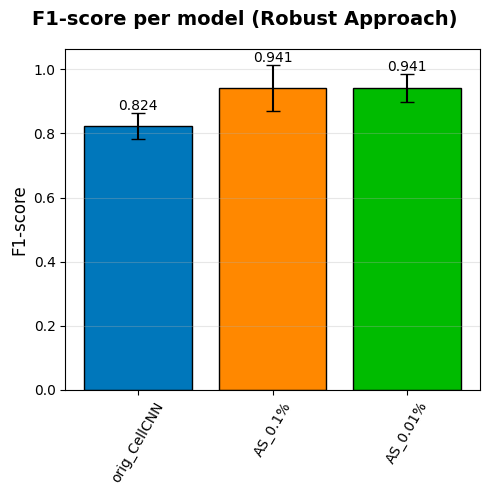

0.97553287745703 0.9977550996792522


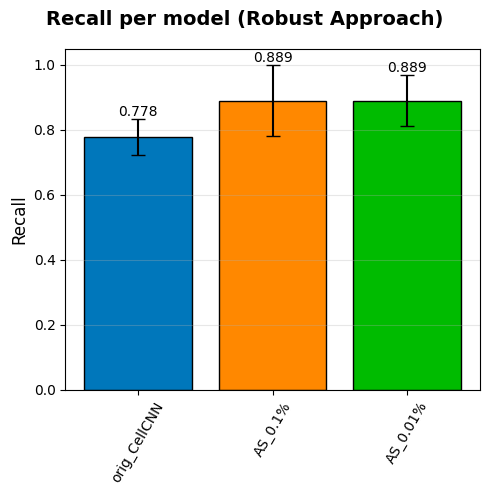

0.9692307692307693 1.0018996212766123


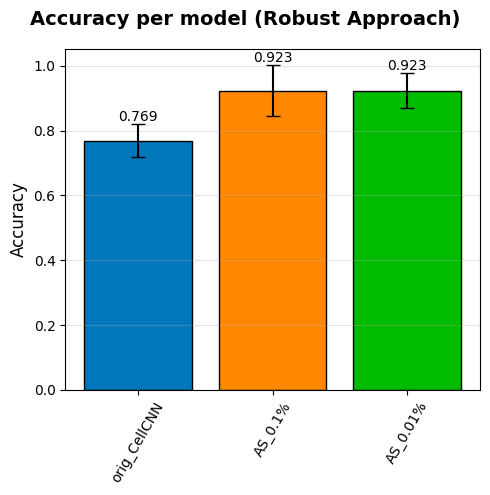

In [20]:
import matplotlib.pyplot as plt
import numpy as np



robust_model_comparison_barplot(all_tested_models, metric = 'f1')
robust_model_comparison_barplot(all_tested_models, metric = 'rec')
robust_model_comparison_barplot(all_tested_models, metric = 'acc')

In [21]:

def direct_model_comparison_barplot(direct, metric_name, subtitle = False):
    
    models_values = list(direct.values())
    models_names = [name.replace('model_', '') for name in direct.keys()]
    
    errors = []
    means = []
    for val in models_values:
        m = np.mean(val)
        means.append(m)
        s = np.std(val)
        errors.append(s)
    
    # Colors matching the plot
    colors = ['#0077BB', '#FF8800', '#00BB00', '#DD0000', '#AA55BB']
    
    # Create bar plot
    fig, ax = plt.subplots(figsize=(5, 5))
    
    bars = ax.bar(models_names, means, yerr= errors, color=colors, edgecolor='black', capsize=5)
    
    for bar, mean, error in zip(bars, means, errors):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + error,
                f'{mean:.3f}',
                ha='center', va='bottom', fontsize=10)
        
    # Customize
    plt.suptitle(f'Direct Prediction {metric_name} per method', fontsize=14, fontweight='bold')
    if subtitle:
        ax.set_title(f'{subtitle}', fontsize=11)
        
    ax.set_ylabel(metric_name, fontsize=12)
    high_limit = np.max(np.array(means) + np.array(errors))
    
    ax.set_ylim(0, max(1, high_limit + 0.05)) # Adjust based on your data range
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.xticks(rotation=60)
    plt.tight_layout()
    
    plt.show()


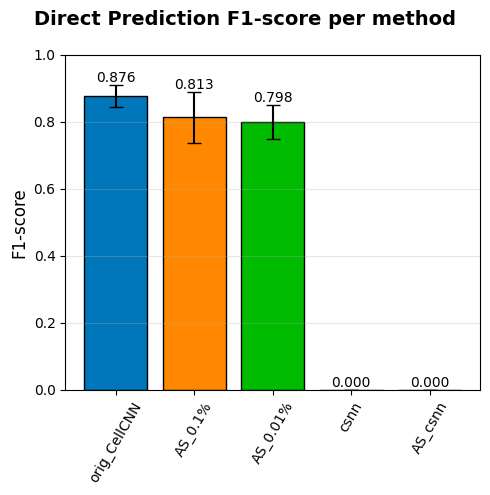

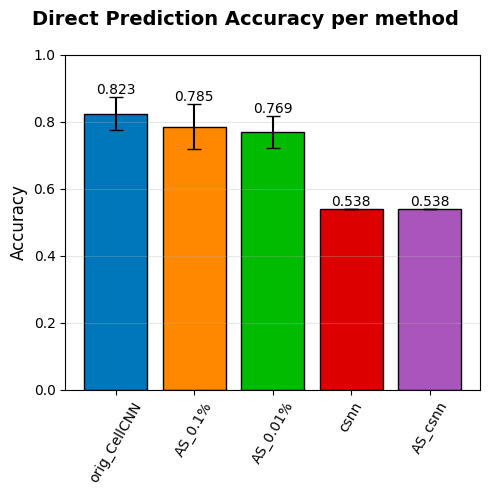

In [22]:
import matplotlib.pyplot as plt
import numpy as np

direct_model_comparison_barplot(direct_f1, 'F1-score')#, subtitle)
direct_model_comparison_barplot(direct_acc, 'Accuracy')#, subtitle)

In [23]:
all_tested_models = {} 
direct_f1 = {}
direct_acc = {}
models = [ 'model_Old_10_11_200_1','model_10_11_200_1', 'model_10_11_500_1',  'model_10_11_1000_1',  'model_10_11_200_0.0001_1']
models_names = ['orig_AS_200', 'AS_200', 'AS_500', 'AS_1000', 'AS_200_0.0001_lr']

model_Old_10_11_200_1
New Generated test datasets
Chosen threshold: 45.0. Associated F1_score: 0.8782287822878229
model_10_11_200_1
New Generated test datasets
Chosen threshold: 48.0. Associated F1_score: 0.8593155893536122
model_10_11_500_1
New Generated test datasets
model_10_11_500_1
model_10_11_1000_1
New Generated test datasets
Chosen threshold: 40.0. Associated F1_score: 0.9455782312925171
model_10_11_200_0.0001_1
New Generated test datasets
Chosen threshold: 42.0. Associated F1_score: 1.0
{'orig_AS_200': [0.9230769230769231, 0.8461538461538461, 0.8461538461538461, 0.8461538461538461, 0.8461538461538461, 0.9230769230769231, 0.6153846153846154, 0.8461538461538461, 0.8461538461538461, 0.8461538461538461], 'AS_200': [0.8461538461538461, 0.9230769230769231, 0.8461538461538461, 0.9230769230769231, 0.8461538461538461, 0.8461538461538461, 0.6923076923076923, 0.9230769230769231, 0.9230769230769231, 0.8461538461538461], 'AS_500': [0.9230769230769231, 1.0, 0.9230769230769231, 0.92307692307

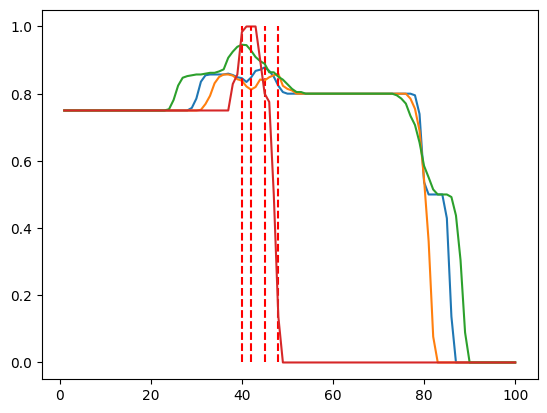

In [24]:
for i, mod in enumerate(models):
    #load data
    per_donor_resampled_test_y , trials_pred_lists, imported_predictions, imported_results, imported_test_y, tot_per_tr_f1_scores, blast_perc = load_saved_data(f'{old_save_path}', mod)

    try:
        threshold = show_threshold_tuning(tot_per_tr_f1_scores)
    except:
        print(mod)
        threshold = tot_per_tr_f1_scores
    
    dir_acc = elaborate_direct_prediction(imported_predictions, imported_test_y, 'acc')
    dir_f1 = elaborate_direct_prediction(imported_predictions, imported_test_y, 'f1')

    mod_n = models_names[i]
    direct_acc[mod_n] = dir_acc
    direct_f1[mod_n] = dir_f1

    metrics_list = elaborate_robust_prediction(trials_pred_lists, imported_test_y, threshold)
    # add the f1_result to the tested model dictionary
    patient_timepoints_labels  = robust_prediction_labelling(trials_pred_lists, threshold)
    test_total_labels = flatten(patient_timepoints_labels)
    all_tested_models[mod_n] = [metrics_list, [patient_timepoints_labels, imported_test_y]] # f1, recall, accuracy


print(direct_acc)
print(direct_f1)

0.969439452351368 0.9860665799771386


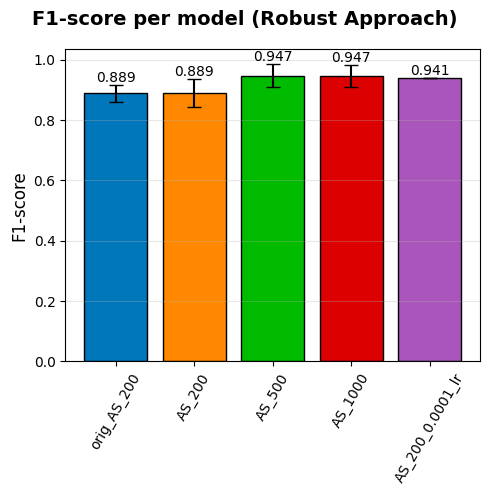

1.0222222222222224 1.0544331053951819


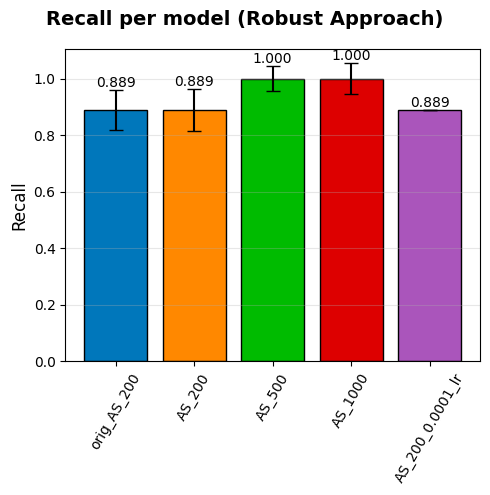

0.9538461538461539 0.9846153846153847


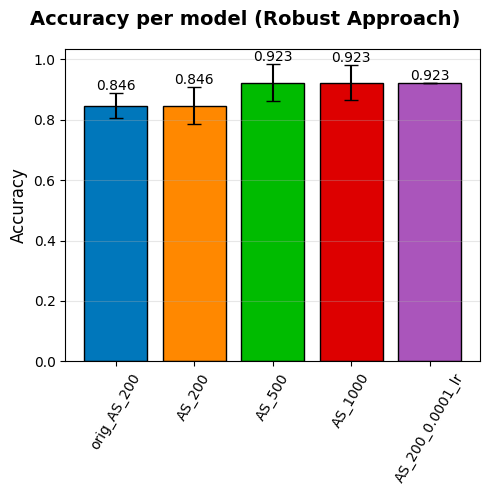

In [30]:
import matplotlib.pyplot as plt
import numpy as np



robust_model_comparison_barplot(all_tested_models, metric = 'f1')
robust_model_comparison_barplot(all_tested_models, metric = 'rec')
robust_model_comparison_barplot(all_tested_models, metric = 'acc')

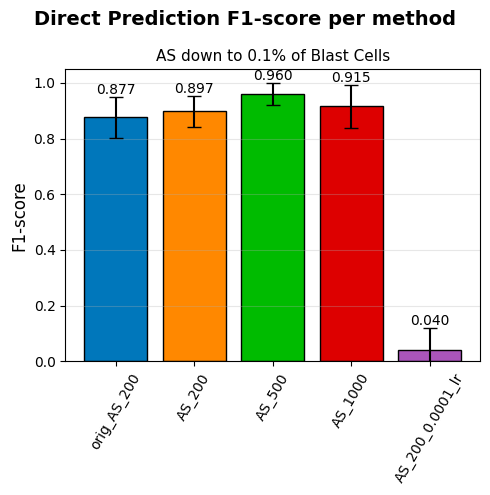

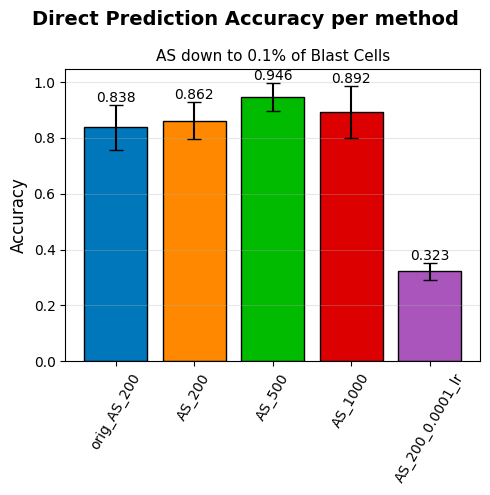

In [28]:
import matplotlib.pyplot as plt
import numpy as np
subtitle = 'AS down to 0.1% of Blast Cells'
direct_model_comparison_barplot(direct_f1, 'F1-score', subtitle)
direct_model_comparison_barplot(direct_acc, 'Accuracy', subtitle)